# Day 15 Pre-Class Assignment: Fitting functions to data (curve-fitting) and thinking more about models

###  &#9989; Put your name here

<br/>
<img src="https://www.mathworks.com/help/examples/matlab/win64/CurveFittingViaOptimizationExample_01.png" alt="Curve-fitting" width=500px/>


## Goals for today's pre-class assignment

* Be able to articulate what regression is and why we use it
* Complete an Ordinary Least Squares function and use it to fit a linear model 
* Use SciPy to fit a specific function to data
* Describe the nature of building and using models to understand the world


## Assignment instructions

**This assignment is due by 11:59 p.m. the day before class,** and should be uploaded into the appropriate "Pre-class assignments" submission folder.  If you run into issues with your code, make sure to use Slack to help each other out and receive some assistance from the instructors. Submission instructions can be found at the end of the notebook.

----
## Part 2: Doing Regression "By Hand"

In last class, you used Python code to find a curve of best fit through a set of data.  This is how you will find best fit curves during this class.  

However, it can be instructive to look at other ways that you might approach a problem.  In this section, you will use an algorithm to find a line of best fit "by hand" instead of using the `SciPy` module.  This is accomplished by calculating the slope and intercept values.  The following video shows how this is done. 


#### Watch this video
If the YouTube video doesn't work, try this [MediaSpace link](https://mediaspace.msu.edu/media/RegressionA+Methods+and+Examples/1_gtg70ib1).

[Regression: Methods and Examples](https://www.youtube.com/watch?v=1YUHyBTztOc)

____
Using what was covered in the previous video, follow along with the code below where we will use ordinary least squares (OLS) solutions to fitting a simple linear regression model. 

First we can make our necessary imports and then generate some data to work with!

In [65]:
# Import our necessary packages
import numpy as np
import matplotlib.pyplot as plt

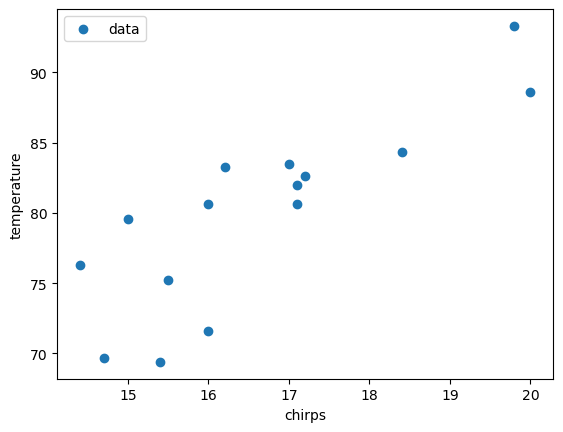

In [67]:
# here is some x and y data of cricket chirps vs. temperature
chirps = np.array([20,16,19.8,18.4,17.1,15.5,14.7,17.1,15.4,16.2,15,17.2,16,17,14.4])
temperature = np.array([88.6,71.6,93.3,84.3,80.6,75.2,69.7,82,69.4,83.3,79.6,82.6,80.6,83.5,76.3])
#plot our data
plt.scatter(chirps, temperature, label = "data")
plt.xlabel("chirps")
plt.ylabel("temperature")
plt.legend()
plt.show()

Look at the plot above. Notice that the relationship between $y$ and $x$ is roughly linear. This means we can use the ordinary least squares (OLS) approach to fit a line to the data. Below is a function that performs OLS.

The equations for linear regression are at in the video, but are repeated here as a reference:

$$\bar{x} = \frac{1}{N}\sum_i x_i$$

$$\bar{y} = \frac{1}{N}\sum_i y_i$$

$$ m = \frac{\sum_i x_i y_i - N\bar{x}\bar{y}}{\sum_i x_i^2 - N\bar{x}^2}$$

$$ b = \bar{y} - m\bar{x}$$

Recall that:
* $x_i$ are the $x$ coordinates, and there are $N$ of them
* $y_i$ are the $y$ values of the data, and there are also $N$ of them
* the sums, $\sum_i$, means that you sum up all of the values that follow; for example, $\sum_ix_i = x_0 + x_1 + \cdots x_{N-1}$

Also note that $\bar{x}$ and $\bar{y}$ represent the mean of $x$ and the mean of $y$, respectively. 

#### &#9989;&nbsp; **2.1** In the function below, comment the code where specified and fill in the equation for calculating $b$, the intercept!

In [ ]:
# This function is used to calculate ordinary least squares regression parameters given some data

def my_ols_parameters(x, y):
    
    # average of x data
    mean_x = np.mean(x)
    
    # average of y data
    mean_y = np.mean(y)
    
    # number of data points we have -- len(y) would work too
    N = len(x)
    
    # the sum of all the x multiplied by all the y
    xy_product_sum = np.sum(x*y)
    
    # the sum of all the x squared
    xx_product_sum = np.sum(x**2)
    
    
    # what is this line doing?
    # comment here
    m = (xy_product_sum - N * mean_x * mean_y)/(xx_product_sum - N*mean_x**2)

    # UNCOMMENT AND FILL IN THIS CODE
    # calculate the intercept using the equation above
    #b = ?
    
    # what does this function return?
    # comment here
    return m, b

The function provided below (no changes to this function are needed) takes in our $x$ data and our estimated slope and intercept values to predict expected $y$ values. We will use this function below when we plot our fitted linear regression model!

In [ ]:
# THIS FUNCTION IS PROVIDED, NO CHANGES NECESSARY
# This function uses a regression equation to predict y given x
# It takes in b (the intercept), m (the coefficient), and
# x (the independent data)

def my_ols_regression(x, m, b):
    
    expected_y = m*x + b
    
    return expected_y

In the cell below, we call our finished `my_ols_parameters` function to calculate our parameters and then feed these into our `my_ols_regression` function to calculate our expected $y$ values.

#### &#9989;&nbsp; **2.2** Comment the code below where specified!

In [ ]:
# comment here - what is m & b?
m_expected, b_expected = my_ols_parameters(chirps, temperature)

# comment here - what are these values?
expected_y = my_ols_regression(chirps, m_expected, b_expected)

# plot our data against our fitted linear regression
plt.scatter(chirps, temperature, label = "data")
plt.plot(chirps, expected_y, color = "orange", label = "fit")

plt.legend()
plt.xlabel('chirps')
plt.ylabel('temperature')
plt.show()

#### &#9989;&nbsp; **2.3** Print out your calculated slope and intercept below. What do these values mean in terms of $x$ and $y$? That is, what does the slope tell you about how $y$ changes when $x$ changes? What information does the intercept provide?

In [ ]:
# Put your code here


&#9998; *Put your answer here.*

----
## Part 3. Review of `curve_fit`

Now, let's use `curve_fit` on the data (`temperature` and `chirps`) from above.  This will serve two purposes:
1. We can use the results to check our work, and
2. We can review the basics of how to use `curve_fit`.

As a reminder, you need to:
* **Define a function that has the equation you want to fit.** In this case, we are fitting $\mathbf{y=mx+b}$.  For function inputs, you will need the independent variable first, followed by any parameters you need to fit.
* **Call the `curve_fit` command** to get the best fit parameters.
* **Plug the best fit parameters into the function you defined** to get the expected values for the dependent variable.
* You should also **plot the function and the data** to see if your results make sense.

A working example from Day 14 PCA is given below to help you.

[1.64659543 1.17088967 0.07707385]


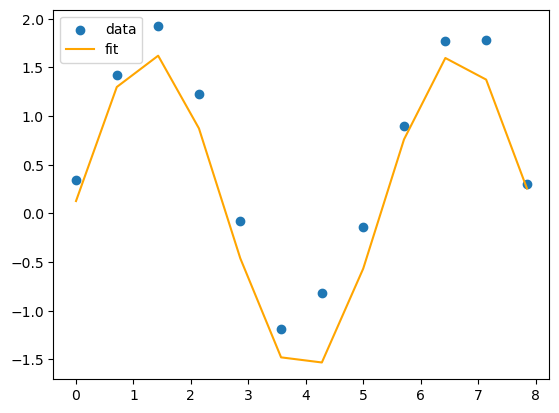

In [93]:
# WORKING EXAMPLE FROM DAY 14 PCA

# start with some data
x = np.array([0.00, 0.71, 1.43, 2.14, 2.86, 3.57, 4.28, 5.00, 5.71, 6.43, 7.14, 7.85])
y = np.array([0.34, 1.42, 1.92, 1.23, -0.08, -1.19, -0.82, -0.14, 0.90, 1.77, 1.78, 0.30])

# define the function you want to fit
def sin_function(x, A, B, C):
    return A * np.sin(B * x + C)

# use curve_fit to get the best fit parameters
best_fit_parameters, just_ignore_this_for_now = curve_fit(sin_function, x, y)
print(best_fit_parameters)

# unpack the best fit parameters
A_expected = best_fit_parameters[0]  
B_expected = best_fit_parameters[1]
C_expected = best_fit_parameters[2]

# use the best fit parameters in your function to get the expected values for your dependent variable
y_expected = sin_function(x, A_expected, B_expected, C_expected)

# plot the results
plt.scatter(x, y, label = "data")
plt.plot(x, y_expected, color = "orange", label = "fit")
plt.legend()

In [ ]:
# put your answer here
# use the temperature and chirps data from the previous part

# Do not delete this line!
plt.savefig

---
## Part 4. More Practice Using `curve_fit`

Letâs put our new curve fitting tools to the test. Weâve provided you with a dataset in the cell below.

#### &#9989;&nbsp; **4.1** First, make a plot showing $x$ vs. $y$ so we can get a sense of what the data looks like.

In [101]:
x = np.array([0.0,0.45,0.9,1.34,1.79,2.24,2.69,3.14,3.59,4.03,4.48,4.93,5.38,5.83,6.28,6.72,7.17,7.62,8.07,8.52,8.97,9.41,9.86,10.31,10.76,11.21,11.66,12.1,12.55,13.0])
y = np.array([0.74,0.92,1.16,1.65,2.23,2.56,2.92,2.9,2.97,2.98,2.54,2.48,2.31,2.3,2.34,2.39,2.94,3.36,3.61,4.1,4.33,4.61,4.78,4.62,4.29,4.17,4.22,3.9,3.98,4.29])

In [103]:
# Make a plot of x vs. y here


We happen to know that this data can be modeled using the following equation: 

\begin{equation}
y = G\cos(x) + Dx +  L_0
\end{equation}


#### &#9989;&nbsp; **4.2** Use `curve_fit` to find the best values for $G$, $D$, and $L_0$.  What values do you get?

**Make sure to name your `curve_fit` parameter variables `G`, `D`, and `L0`.**

In [ ]:
# Write your function here


#### &#9989;&nbsp; **4.3** Use your best fit parameters, to plot a best-fit line.  Also plot the data in the same figure.

In [ ]:
# Write your code for finding a line of best fit here

# Do not delete this line!
plt.savefig()

#### &#9989;&nbsp; **4.4** Is your function a good fit for this dataset?

&#9998; *Record your thoughts here*

## 5. Evaluating Exported Visualizations

We've made several visualizations so far in this course, but one thing we haven't explored is how to best export the visualizations you make for others to view in presentations, articles, etc.

&#9989;&nbsp; **5.1** Access the provided pdf from the [Course Website](cmse.msu.edu/cmse201) under Day 15. It has a few different examples of exported plots from matplotlib. Then, answer the questions below for each slide:

1. What stands out to you about this example?
2. Identify one problem you see with the plot, and write it down here in the form of a question you would ask Google or HiTA.
3. Ask Google/HiTA your question, what solutions does it provide? If this happened with one of your visualizations, how would you fix it?

&#9998; *Put your answer here.*

* Slide 1:

* Slide 2:

* Slide 3:

---
## Assignment wrap-up

Please fill out the form that appears when you run the code below.  **You must completely fill this out in order to receive credit for the assignment!**

[Pre-class survey](https://cmse.msu.edu/cmse201-pc-survey)

### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  Go to the "Pre-class assignments" folder, find the appropriate submission link, and upload it there.

See you in class!

&#169; Copyright 2024,  [Department of Computational Mathematics, Science and Engineering](https://cmse.msu.edu) at Michigan State University.